# Imputation des valeurs manquantes avec KNNImputer

La colonne `total_bedrooms` contient 207 valeurs manquantes. Plutôt que de les remplir avec la médiane, on utilise **KNNImputer** qui prédit chaque valeur manquante à partir des k plus proches voisins complets.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

plt.rcParams['figure.figsize'] = (12, 8)
sns.set()
sns.set_context('talk')

## 1. Chargement et état des lieux

In [13]:
housing = pd.read_csv('./data/housing.csv')
print(f"Shape : {housing.shape}")
print(f"\nValeurs manquantes :")
print(housing.isnull().sum())
print(f"\n→ {housing['total_bedrooms'].isnull().sum()} lignes sans total_bedrooms sur {len(housing)}")

Shape : (20640, 10)

Valeurs manquantes :
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

→ 207 lignes sans total_bedrooms sur 20640


In [14]:
# Indices des lignes avec valeurs manquantes (pour vérification après imputation)
missing_idx = housing[housing['total_bedrooms'].isnull()].index
print(f"{len(missing_idx)} lignes à imputer")
print(f"Exemples d'indices : {list(missing_idx[:10])}")

207 lignes à imputer
Exemples d'indices : [290, 341, 538, 563, 696, 738, 1097, 1350, 1456, 1493]


## 2. Préparation pour KNNImputer

KNNImputer ne gère que des données numériques. On encode `ocean_proximity` temporairement avec LabelEncoder, puis on standardise les données pour que la distance euclidienne soit cohérente entre les colonnes.

In [15]:
# Encodage de ocean_proximity
le = LabelEncoder()
housing['ocean_proximity_encoded'] = le.fit_transform(housing['ocean_proximity'])
print("Mapping ocean_proximity :")
for i, label in enumerate(le.classes_):
    print(f"  {label} → {i}")

Mapping ocean_proximity :
  <1H OCEAN → 0
  INLAND → 1
  ISLAND → 2
  NEAR BAY → 3
  NEAR OCEAN → 4


In [16]:
# Colonnes numériques pour l'imputation
num_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
            'total_bedrooms', 'population', 'households', 'median_income',
            'median_house_value', 'ocean_proximity_encoded']

X = housing[num_cols].copy()

In [17]:
# Standardisation avant KNN (important pour la distance euclidienne)
scaler = StandardScaler()

# On fit le scaler sur les colonnes sans NaN pour ne pas biaiser
# KNNImputer gère les NaN en interne, mais on doit standardiser d'abord
# On standardise toutes les colonnes sauf total_bedrooms, puis on scale total_bedrooms
# séparément sur les valeurs non-nulles

# Approche : standardiser manuellement
means = X.mean()
stds = X.std()
X_scaled = (X - means) / stds

print("Données standardisées (les NaN sont préservés) :")
print(f"NaN restants : {X_scaled.isnull().sum().sum()}")

Données standardisées (les NaN sont préservés) :
NaN restants : 207


## 3. Imputation avec KNNImputer (k=5)

In [18]:
# KNNImputer avec k=5 voisins
imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed_scaled = imputer.fit_transform(X_scaled)

# Dé-standardiser pour revenir aux valeurs originales
X_imputed = pd.DataFrame(
    X_imputed_scaled * stds.values + means.values,
    columns=num_cols,
    index=X.index
)

print(f"Valeurs manquantes après imputation : {X_imputed.isnull().sum().sum()}")

Valeurs manquantes après imputation : 0


In [19]:
# Remplacement de total_bedrooms dans le dataframe original
housing['total_bedrooms'] = X_imputed['total_bedrooms'].round(0)

# Vérification
print("Valeurs manquantes après imputation :")
print(housing.isnull().sum())

Valeurs manquantes après imputation :
longitude                  0
latitude                   0
housing_median_age         0
total_rooms                0
total_bedrooms             0
population                 0
households                 0
median_income              0
median_house_value         0
ocean_proximity            0
ocean_proximity_encoded    0
dtype: int64


## 4. Vérification des valeurs imputées

In [20]:
# Valeurs imputées
imputed_values = housing.loc[missing_idx, 'total_bedrooms']
print(f"Statistiques des {len(imputed_values)} valeurs imputées :")
print(imputed_values.describe())
print(f"\nStatistiques de total_bedrooms (complet) :")
print(housing['total_bedrooms'].describe())

Statistiques des 207 valeurs imputées :
count     207.000000
mean      531.487923
std       378.964966
min        66.000000
25%       273.500000
50%       451.000000
75%       664.500000
max      3235.000000
Name: total_bedrooms, dtype: float64

Statistiques de total_bedrooms (complet) :
count    20640.000000
mean       537.806541
std        420.973052
min          1.000000
25%        296.000000
50%        435.000000
75%        647.000000
max       6445.000000
Name: total_bedrooms, dtype: float64


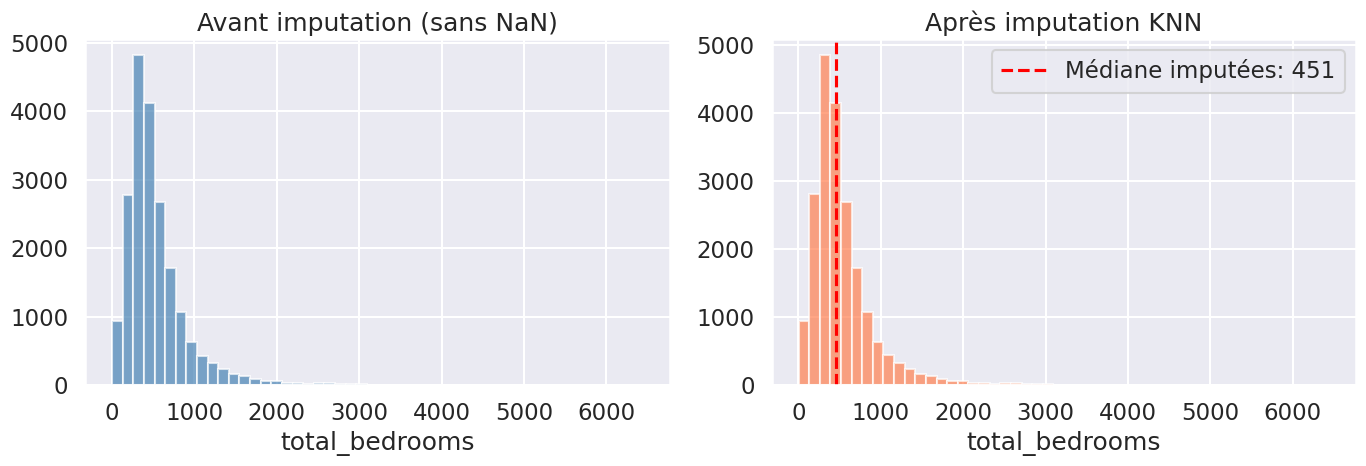

In [21]:
# Comparaison visuelle : distribution avant/après
original = pd.read_csv('./data/housing.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(original['total_bedrooms'].dropna(), bins=50, alpha=0.7, color='steelblue')
axes[0].set_title('Avant imputation (sans NaN)')
axes[0].set_xlabel('total_bedrooms')

axes[1].hist(housing['total_bedrooms'], bins=50, alpha=0.7, color='coral')
axes[1].axvline(imputed_values.median(), color='red', linestyle='--', label=f'Médiane imputées: {imputed_values.median():.0f}')
axes[1].set_title('Après imputation KNN')
axes[1].set_xlabel('total_bedrooms')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Export du dataset complet

In [22]:
# Suppression de la colonne encodée temporaire
housing = housing.drop(columns=['ocean_proximity_encoded'])

output_path = './data/housing_data_knn.csv'
housing.to_csv(output_path, index=False)
print(f"Dataset complet exporté : {output_path}")
print(f"Shape : {housing.shape}")
print(f"Valeurs manquantes : {housing.isnull().sum().sum()}")
housing.head()

Dataset complet exporté : ./data/housing_data_knn.csv
Shape : (20640, 10)
Valeurs manquantes : 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
